In [1]:
# Install required dependencies
import subprocess
import sys

packages = [
    "tensorflow>=2.13.0",
    "keras>=2.13.0",
    "datasets>=2.14.0",
    "pillow>=10.0.0",
    "protobuf>=3.20.0",
    "numpy>=1.24.0",
    "pandas>=2.0.0",
    "matplotlib>=3.8.0",
    "seaborn>=0.13.0",
    "scikit-learn>=1.3.0",
]

print("Installing dependencies...")
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("✓ All dependencies installed")

# Verify imports
import importlib
versions = {}
for pkg in ["tensorflow", "keras", "datasets", "PIL", "numpy", "pandas"]:
    try:
        mod = importlib.import_module(pkg)
        versions[pkg] = getattr(mod, "__version__", "installed")
    except ImportError as e:
        versions[pkg] = f"ERROR: {e}"

for pkg, ver in versions.items():
    print(f"{pkg}: {ver}")

Installing dependencies...
✓ All dependencies installed


c:\Users\totot\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


tensorflow: 2.20.0
keras: 3.13.0
datasets: 4.4.2
PIL: 10.2.0
numpy: 1.26.4
pandas: 2.1.4


# AI vs Real Image Classifier (TensorFlow/Keras)

Goal: train a CNN to classify real vs AI-generated images using the Hugging Face dataset `Hemg/AI-Generated-vs-Real-Images-Datasets`, then export a web-ready model (.h5 and SavedModel) plus a simple inference helper.

Outline follows the provided template, adapted for this computer-vision task.

## 2) Configure Notebook Settings

In [2]:
%load_ext autoreload
%autoreload 2

import logging
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

## 3) Import Libraries

In [3]:
import os, json, random, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split


## 4) Seed Random Generators

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seeded RNGs with", SEED)

Seeded RNGs with 42


## 5) Define Utility Functions and Constants

In [4]:
PROJECT_ROOT = Path.cwd()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
MODEL_H5_PATH = ARTIFACTS_DIR / "ai_vs_real_cnn.h5"
MODEL_SAVEDMODEL_DIR = ARTIFACTS_DIR / "ai_vs_real_savedmodel"
DATASET_NAME = "Hemg/AI-Generated-vs-Real-Images-Datasets"
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 2

sns.set_theme(style="whitegrid")


def time_it(fn):
    def wrapped(*args, **kwargs):
        start = time.time()
        result = fn(*args, **kwargs)
        print(f"{fn.__name__} took {time.time() - start:.2f}s")
        return result
    return wrapped


def show_examples(ds, n=6):
    n = min(n, len(ds))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, example in zip(axes, ds.select(range(n))):
        ax.imshow(example["image"])
        ax.set_title(f"label={example['label']}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 6) Load Data (Hugging Face dataset)

In [6]:
dataset = load_dataset(DATASET_NAME, split="train", streaming=False)
print(dataset)
print("Features:", dataset.features)

# Cast image column explicitly; adjust the column names if the dataset card changes
if "image" in dataset.column_names:
    dataset = dataset.cast_column("image", Image())
else:
    raise ValueError("Expected an 'image' column; please inspect dataset.column_names")

# Basic split train/val/test
train_val_test = dataset.train_test_split(test_size=0.2, seed=SEED)
val_test = train_val_test["test"].train_test_split(test_size=0.5, seed=SEED)
train_ds = train_val_test["train"]
val_ds = val_test["train"]
test_ds = val_test["test"]

print("Split sizes:", len(train_ds), len(val_ds), len(test_ds))

[INFO] HTTP Request: HEAD https://huggingface.co/datasets/Hemg/AI-Generated-vs-Real-Images-Datasets/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
[INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Hemg/AI-Generated-vs-Real-Images-Datasets/e270a0ad14b3b18a80a78d64e8ad5ec3eb6f798c/README.md "HTTP/1.1 200 OK"
[INFO] HTTP Request: HEAD https://huggingface.co/datasets/Hemg/AI-Generated-vs-Real-Images-Datasets/resolve/e270a0ad14b3b18a80a78d64e8ad5ec3eb6f798c/AI-Generated-vs-Real-Images-Datasets.py "HTTP/1.1 404 Not Found"
[INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/Hemg/AI-Generated-vs-Real-Images-Datasets/Hemg/AI-Generated-vs-Real-Images-Datasets.py "HTTP/1.1 404 Not Found"
[INFO] HTTP Request: GET https://huggingface.co/api/datasets/Hemg/AI-Generated-vs-Real-Images-Datasets/revision/e270a0ad14b3b18a80a78d64e8ad5ec3eb6f798c "HTTP/1.1 200 OK"
[INFO] HTTP Request: HEAD https://huggingface.co/datasets/Hemg/AI-

Dataset({
    features: ['image', 'label'],
    num_rows: 152710
})
Features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['AiArtData', 'RealArt'])}
Split sizes: 122168 15271 15271


## 7) Validate and Clean Data

In [8]:
# Quick schema/checks
print("Columns:", train_ds.column_names)

label_col = "label"
if label_col not in train_ds.column_names:
    raise ValueError("Expected a 'label' column; please inspect dataset.column_names")

print("Unique labels:", train_ds.unique(label_col))
print("Class distribution (train):")
print(pd.Series(train_ds[label_col]).value_counts())

# Remove entries with missing images
train_ds = train_ds.filter(lambda example: example["image"] is not None)
val_ds = val_ds.filter(lambda example: example["image"] is not None)
test_ds = test_ds.filter(lambda example: example["image"] is not None)


Columns: ['image', 'label']
Unique labels: [1, 0]
Class distribution (train):
0    64937
1    57231
Name: count, dtype: int64


## 8) Exploratory Data Analysis

[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


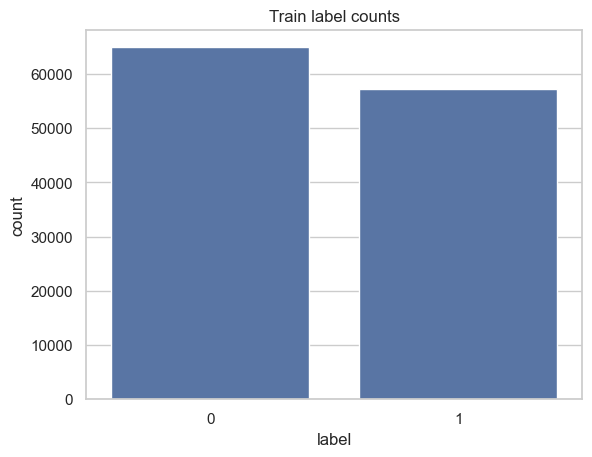

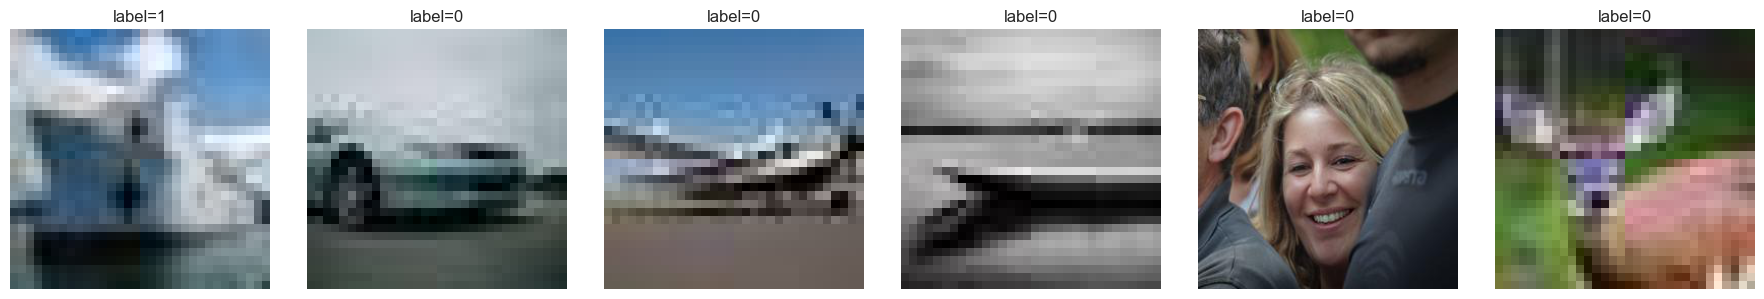

In [9]:
# Label distribution
train_labels = pd.Series(train_ds[label_col], name="label")
ax = sns.countplot(x=train_labels)
ax.set_title("Train label counts")
plt.show()

show_examples(train_ds, n=6)

## 9) Feature Engineering

In [19]:
def preprocess_image(img):
    """Preprocess image: handle shape, resize, normalize."""
    try:
        img_array = np.array(img)
        
        if len(img_array.shape) == 2:
            img_array = np.expand_dims(img_array, -1)
            img_array = np.repeat(img_array, 3, axis=-1)
        elif len(img_array.shape) == 3:
            if img_array.shape[-1] == 1:
                img_array = np.repeat(img_array, 3, axis=-1)
            elif img_array.shape[-1] == 4:
                img_array = img_array[..., :3]
            elif img_array.shape[-1] != 3:
                return None
        else:
            return None
        
        if len(img_array.shape) != 3 or img_array.shape[-1] != 3:
            return None
        
        img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
        img_tensor = tf.image.resize(img_tensor, (IMG_SIZE, IMG_SIZE))
        img_tensor = tf.cast(img_tensor, tf.float32) / 255.0
        return img_tensor
    except Exception as e:
        return None


print("Testing preprocessing on sample images...")
test_sample = train_ds.select(range(min(100, len(train_ds))))
valid_count = 0
for example in test_sample:
    if preprocess_image(example["image"]) is not None:
        valid_count += 1

print(f"Sample test: {valid_count}/100 images processed successfully")
if valid_count < 10:
    logging.error("❌ Very few valid images. Dataset is corrupted.")
    raise ValueError("Dataset preprocessing failed.")


def create_tf_dataset(ds, shuffle=True, max_examples=None):
    """Convert HuggingFace dataset to tf.data.Dataset by materializing to memory."""
    print(f"  Loading and preprocessing {len(ds)} images...")
    
    images = []
    labels = []
    skipped = 0
    
    for i, example in enumerate(ds):
        if i % 1000 == 0:
            print(f"    Progress: {i}/{len(ds)}")
        
        if max_examples and len(images) >= max_examples:
            break
        
        try:
            if example.get("image") is None:
                skipped += 1
                continue
            
            processed_img = preprocess_image(example["image"])
            if processed_img is None:
                skipped += 1
                continue
            
            img = processed_img.numpy()
            label = int(example[label_col])
            images.append(img)
            labels.append(label)
        except Exception as e:
            skipped += 1
            continue
    
    if len(images) == 0:
        raise ValueError(f"No valid images found! Skipped {skipped}/{len(ds)}")
    
    print(f"  ✓ Loaded {len(images)} images, skipped {skipped}")
    
    # Convert to numpy arrays
    images_array = np.array(images, dtype=np.float32)
    labels_array = np.array(labels, dtype=np.int64)
    
    # Create tf.data.Dataset from tensors (known cardinality)
    dataset = tf.data.Dataset.from_tensor_slices((images_array, labels_array))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(images), 5000))
    
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset, len(images)


print("\nCreating TF datasets...")
train_tf, train_count = create_tf_dataset(train_ds, shuffle=True)
val_tf, val_count = create_tf_dataset(val_ds, shuffle=False)
test_tf, test_count = create_tf_dataset(test_ds, shuffle=False)

print("\nDataset Summary:")
print(f"  Train: {train_count} images → {train_tf.cardinality().numpy()} batches")
print(f"  Val:   {val_count} images → {val_tf.cardinality().numpy()} batches")
print(f"  Test:  {test_count} images → {test_tf.cardinality().numpy()} batches")

# Safety check
if train_tf.cardinality() <= 0:
    raise ValueError("❌ Training dataset has no batches!")

print("✓ Done!")

Testing preprocessing on sample images...
Sample test: 100/100 images processed successfully

Creating TF datasets...
  Loading and preprocessing 122168 images...
    Progress: 0/122168
    Progress: 1000/122168
    Progress: 2000/122168
    Progress: 3000/122168
    Progress: 4000/122168
    Progress: 5000/122168
    Progress: 6000/122168
    Progress: 7000/122168
    Progress: 8000/122168
    Progress: 9000/122168
    Progress: 10000/122168
    Progress: 11000/122168
    Progress: 12000/122168
    Progress: 13000/122168
    Progress: 14000/122168
    Progress: 15000/122168
    Progress: 16000/122168
    Progress: 17000/122168
    Progress: 18000/122168
    Progress: 19000/122168
    Progress: 20000/122168
    Progress: 21000/122168
    Progress: 22000/122168
    Progress: 23000/122168
    Progress: 24000/122168
    Progress: 25000/122168
    Progress: 26000/122168
    Progress: 27000/122168
    Progress: 28000/122168
    Progress: 29000/122168
    Progress: 30000/122168
    Progress:

## 10) Model Training (Baseline CNN)

In [24]:
def build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="ai_vs_real_cnn")
    return model

model = build_model()
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

MODEL_KERAS_PATH = ARTIFACTS_DIR / "ai_vs_real_cnn.keras"
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath=str(MODEL_KERAS_PATH), save_best_only=True),
]

print(f"Starting training with {train_count} training images...")
history = model.fit(
    train_tf,
    validation_data=val_tf,
    epochs=10,
    callbacks=callbacks,
)

Model: "ai_vs_real_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Starting training with 122168 training images...
Epoch 1/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 315s 75ms/step - accuracy: 0.8064 - loss: 0.4049 - val_accuracy: 0.8766 - val_loss: 0.2908
Epoch 2/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 336s 88ms/step - accuracy: 0.8958 - loss: 0.2425 - val_accuracy: 0.9003 - val_loss: 0.2372
Epoch 3/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 340s 89ms/step - accuracy: 0.9191 - loss: 0.1937 - val_accuracy: 0.9143 - val_loss: 0.1997
Epoch 4/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 330s 87ms/step - accuracy: 0.9335 - loss: 0.1612 - val_accuracy: 0.9085 - val_loss: 0.2238
Epoch 5/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 368s 96ms/step - accuracy: 0.9457 - loss: 0.1331 - val_accuracy: 0.9219 - val_loss: 0.2089
Epoch 6/10
3818/3818 ━━━━━━━━━━━━━━━━━━━━ 336s 88ms/step - accuracy: 0.9553 - loss: 0.1119 - val_accuracy: 0.9175 - val_loss: 0.2225


## 11) Model Evaluation and Cross-Validation

478/478 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.9134 - loss: 0.2009
Test metrics: {'loss': 0.20091912150382996, 'compile_metrics': 0.9133651852607727}
478/478 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9143 - loss: 0.1997
Val metrics: {'loss': 0.19967898726463318, 'compile_metrics': 0.914281964302063}


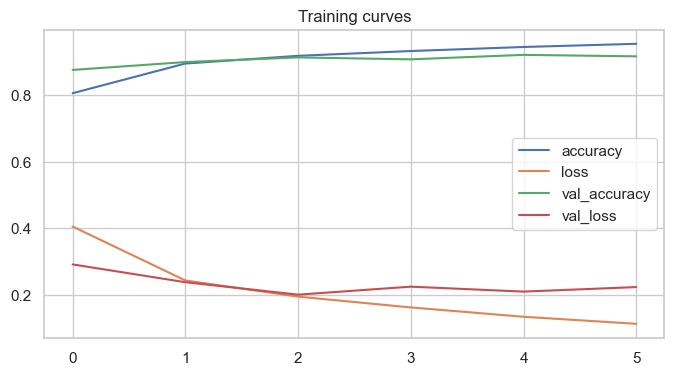

In [25]:
test_metrics = model.evaluate(test_tf)
print("Test metrics:", dict(zip(model.metrics_names, test_metrics)))

# Basic cross-val style check: evaluate on val again (placeholder for full CV if needed)
val_metrics = model.evaluate(val_tf)
print("Val metrics:", dict(zip(model.metrics_names, val_metrics)))

# Plot learning curves
pd.DataFrame(history.history).plot(figsize=(8,4))
plt.title("Training curves")
plt.show()

## 12) Save/Load Models and Artifacts

In [27]:
# Save best weights already handled via ModelCheckpoint (.h5)
MODEL_KERAS_PATH.parent.mkdir(exist_ok=True)
model.save(MODEL_KERAS_PATH)
print(f"✓ Model saved to {MODEL_KERAS_PATH}")

# Also export a SavedModel directory for TF Serving / TF.js conversion
MODEL_SAVEDMODEL_DIR.mkdir(exist_ok=True)
model.export(str(MODEL_SAVEDMODEL_DIR))
print(f"✓ SavedModel exported to {MODEL_SAVEDMODEL_DIR}")

# Reload smoke test
reloaded = keras.models.load_model(MODEL_KERAS_PATH)
print("✓ Reloaded model outputs shape:", reloaded(tf.zeros([1, IMG_SIZE, IMG_SIZE, 3])).shape)

✓ Model saved to c:\vscode projects\realorai\artifacts\ai_vs_real_cnn.keras
INFO:tensorflow:Assets written to: c:\vscode projects\realorai\artifacts\ai_vs_real_savedmodel\assets


[INFO] Assets written to: c:\vscode projects\realorai\artifacts\ai_vs_real_savedmodel\assets


Saved artifact at 'c:\vscode projects\realorai\artifacts\ai_vs_real_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_55')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1673992532240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674056039504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674056033552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674056038544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674179891408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674179887376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674179891024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674179891984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674179892368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1674179890640: TensorSpec(shape=(), dtype=tf.resource, n

## (Extra) Inference Helper

In [ ]:
from PIL import Image

def predict_image(path, model_path=MODEL_H5_PATH):
    if model_path is None:
        model_path = MODEL_KERAS_PATH
    
    model = keras.models.load_model(model_path)
    img = Image.open(path).convert("RGB")
    processed = preprocess_image(img)
    if processed is None:
        raise ValueError(f"Failed to preprocess image: {path}")
    
    tensor = processed[tf.newaxis, ...]
    probs = model.predict(tensor)[0]
    pred = int(np.argmax(probs))
    confidence = float(np.max(probs))
    return {"pred": pred, "confidence": confidence, "probs": probs.tolist()}

# Example:
# result = predict_image("path/to/your/image.jpg")
# print(result)

## 13) Unit Tests (pytest) in Notebook

In [ ]:
import sys, tempfile, textwrap, subprocess

test_code = textwrap.dedent(
    """
    import numpy as np
    import tensorflow as tf
    from PIL import Image

    IMG_SIZE = 128

    def preprocess_image(img):
        img = tf.convert_to_tensor(np.array(img))
        if img.shape[-1] == 4:
            img = img[..., :3]
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        return img

    def test_preprocess_image_shape():
        img = Image.fromarray(np.zeros((200, 200, 3), dtype=np.uint8))
        out = preprocess_image(img)
        assert out.shape == (IMG_SIZE, IMG_SIZE, 3)
        assert tf.reduce_max(out).numpy() <= 1.0
    """
)

with tempfile.NamedTemporaryFile("w", suffix="_test.py", delete=False) as f:
    f.write(test_code)
    test_path = f.name

result = subprocess.run([sys.executable, "-m", "pytest", "-q", test_path])
print("pytest exit code:", result.returncode)


## 14) Parameterization and Configuration

In [ ]:
CONFIG = {
    "dataset": DATASET_NAME,
    "img_size": int(os.getenv("IMG_SIZE", IMG_SIZE)),
    "batch_size": int(os.getenv("BATCH_SIZE", BATCH_SIZE)),
    "seed": int(os.getenv("SEED", SEED)),
}
CONFIG

## 15) Export Results and Visualizations

In [ ]:
metrics_path = ARTIFACTS_DIR / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump({"test": dict(zip(model.metrics_names, test_metrics))}, f, indent=2)
print("Saved metrics to", metrics_path)

# Save a few predictions for reference
sample_preds = []
for batch_imgs, batch_labels in test_tf.take(3):
    probs = model.predict(batch_imgs)
    preds = probs.argmax(axis=1)
    for label, pred in zip(batch_labels.numpy().tolist(), preds.tolist()):
        sample_preds.append({"label": int(label), "pred": int(pred)})

preds_path = ARTIFACTS_DIR / "sample_predictions.csv"
pd.DataFrame(sample_preds).to_csv(preds_path, index=False)
print("Saved sample predictions to", preds_path)

# Optional: export notebook as HTML (requires nbconvert)
print("To export HTML: run !jupyter nbconvert --to html ai_vs_real.ipynb")